In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import QuantileTransformer, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [10]:
df = pd.read_csv("./data/pakwheels_data.csv")

df.drop(['name', 'time'], axis=1, inplace=True)

df.head()

,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
0,Toyota,1997,100000,Petrol,Automatic,2700,Gujrat,4100000
1,Suzuki,1991,130000,Petrol,Manual,1000,Gujrat,1100000
2,Honda,2004,250000,Petrol,Automatic,1300,Lahore,1825000
3,Honda,2005,250000,Petrol,Manual,1300,Lahore,1625000
4,Toyota,2003,100000,Petrol,Automatic,1300,Karachi,1500000


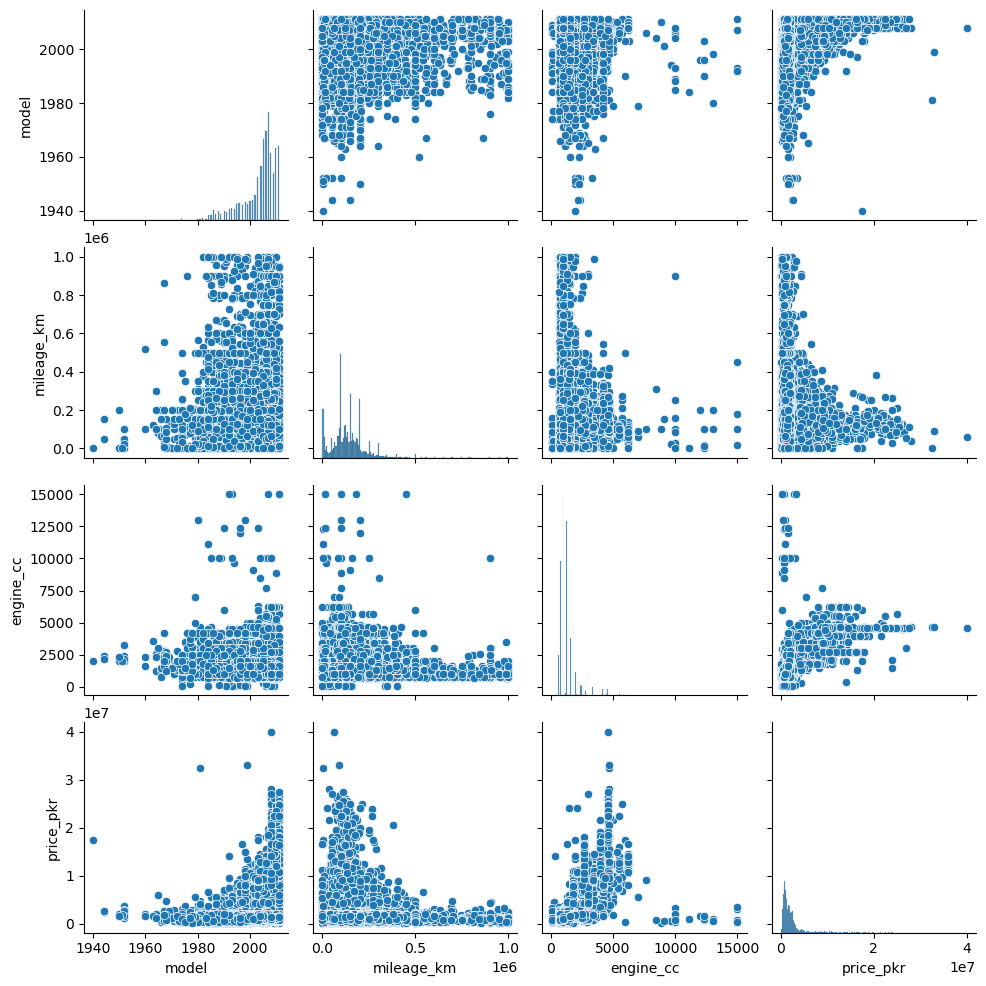

In [11]:
sns.pairplot(df)

<Axes: ylabel='Count'>

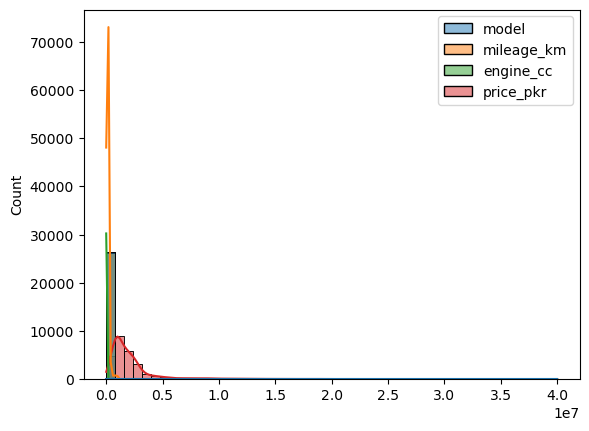

In [12]:
sns.histplot(df, bins=50, kde=True)

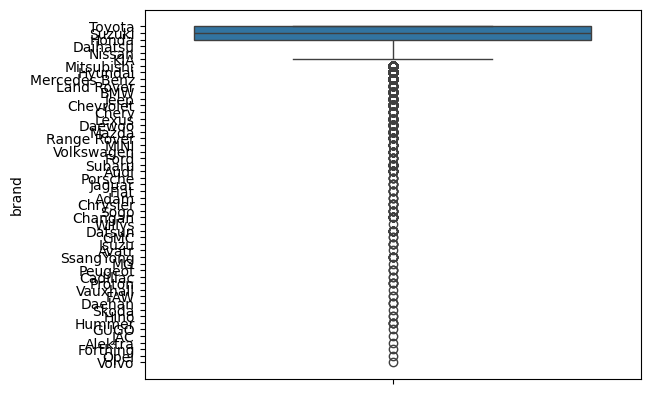

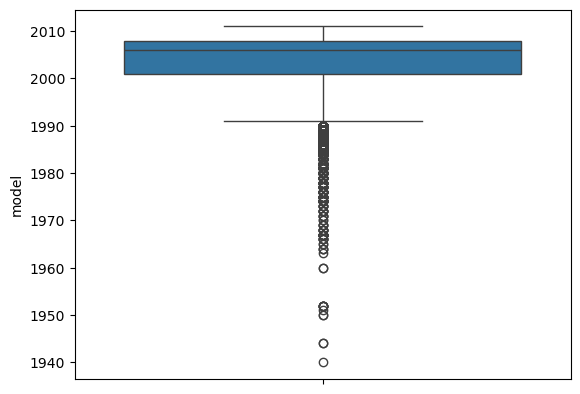

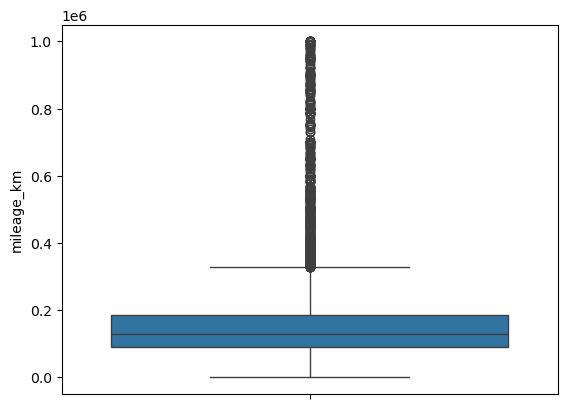

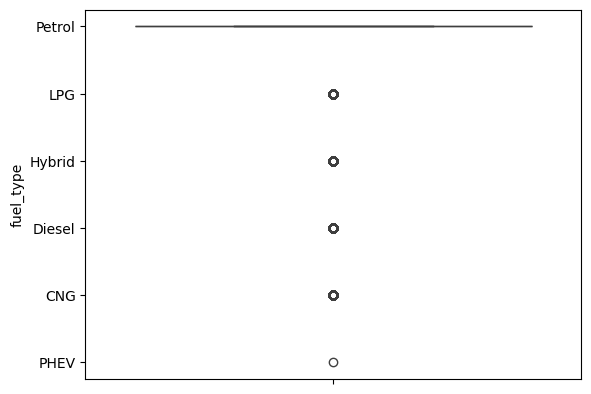

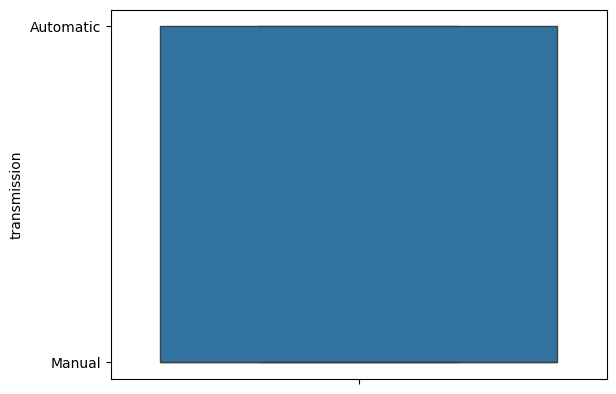

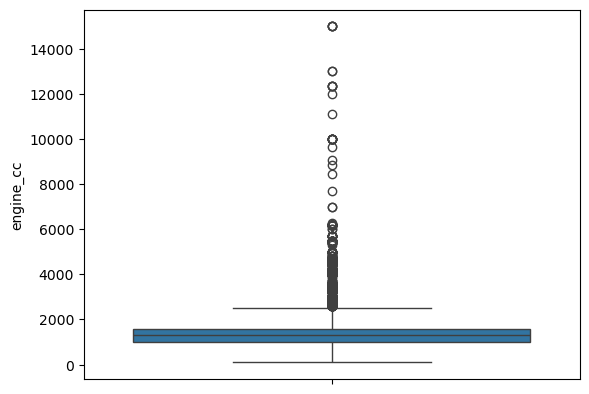

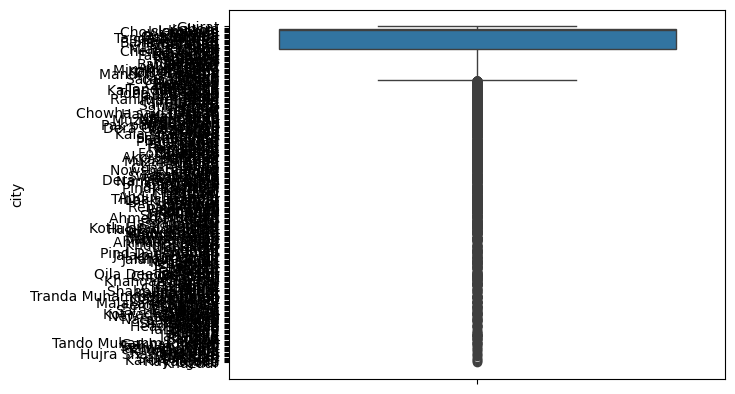

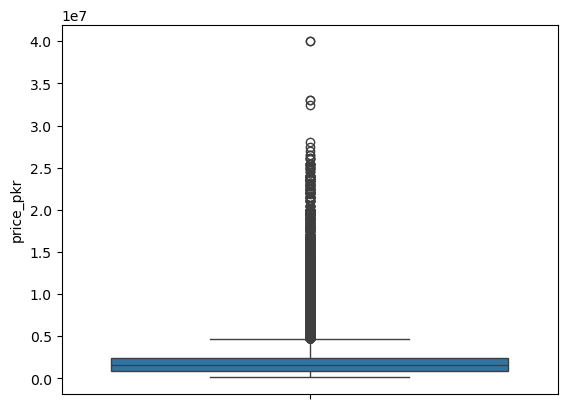

In [13]:
for col in df.columns:
    sns.boxplot(y=df[col])
    plt.show()

- data is right skewed. We will apply log transformation
- we will scale numeric variables using Standard Scalar
- we will remove outliers using 
- we gonna encode categorical features using OneHot Encoder

<Axes: ylabel='Count'>

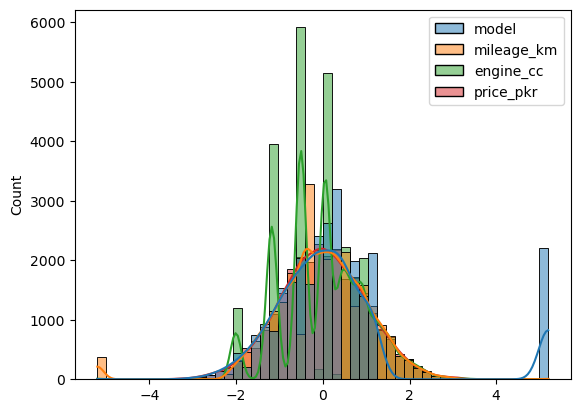

In [14]:
quantile_transformer = QuantileTransformer(output_distribution='normal')

numeric_features = ['mileage_km', 'engine_cc', 'model', 'price_pkr']

for cols in numeric_features:
    df[cols] = quantile_transformer.fit_transform(df[[cols]])

sns.histplot(df, bins=50, kde=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26404 entries, 0 to 26403
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         26404 non-null  object 
 1   model         26404 non-null  float64
 2   mileage_km    26404 non-null  float64
 3   fuel_type     26404 non-null  object 
 4   transmission  26404 non-null  object 
 5   engine_cc     26404 non-null  float64
 6   city          26404 non-null  object 
 7   price_pkr     26404 non-null  float64
dtypes: float64(4), object(4)
memory usage: 1.6+ MB


In [16]:
# categorical_features = ['brand', 'fuel_type', 'transmission', 'city']

for cols in df.select_dtypes('object').columns:
    le = LabelEncoder()
    df[cols] = le.fit_transform(df[cols])

In [17]:
df.head()

,brand,model,mileage_km,fuel_type,transmission,engine_cc,city,price_pkr
0,47,-0.961429,-0.410169,5,0,1.355761,72,1.280981
1,46,-1.431971,0.027604,5,1,-0.504922,72,-0.418371
2,21,-0.338834,1.295363,5,0,0.055229,146,0.207223
3,21,-0.140977,1.295363,5,1,0.055229,146,0.050204
4,47,-0.492137,-0.410169,5,0,0.055229,115,-0.027604


In [26]:
X = df.drop('price_pkr', axis=1)
y = df['price_pkr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R^2 Score:', r2_score(y_test, y_pred))
print('MAE Score:', mean_absolute_error(y_test, y_pred))
print('MAPE Score:', mean_absolute_percentage_error(y_test, y_pred))


Mean Squared Error: 0.3277145128836597
R^2 Score: 0.6764210368668568
MAE Score: 0.43364992133497554
MAPE Score: 13052995504417.645
